Modify from v31.

Correct the problem of leaving blank before h filter

But, it does stitching before convolution

2026.06.01

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from PIL import Image
import cv2
from scipy.signal.windows import tukey
from skimage import data
from collections import defaultdict
import torch.nn.functional as F
from scipy.signal import fftconvolve
from torch.fft import irfftn, rfftn
import torch

/home/xz127/anaconda3/envs/neuws/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
VERSION = 31 # Version number for the code

AP_L = 120  # Long axis of rectangular aperture
AP_W = int(AP_L/10) # Short axis of rectangular aperture (equivalent to 20cm, keeping 10:1 ratio)
N_APERTURES = 16    # Number of different rotation angles to use
ANGLES = np.linspace(0, 180, N_APERTURES, endpoint=False)
LENGTH = 1024 # Length of the image
WIDTH = 512
C_SIZE = 1200 # canvas size
H_NUM = 2   # Number of rows for plotting
W_NUM = 8   # Number of columns for plotting

IMG_PATH = '/home/xz127/earth_project/Reconstruction/test3_1600_1200.jpg'
SAVE_PATH = f'/home/xz127/earth_project/Reconstruction/{N_APERTURES}AP_combined_result_v{VERSION}.jpg'

In [3]:


def crop_and_stitch(image, phi_ap_degrees, L=LENGTH, W=WIDTH, canvas_size=C_SIZE, sigma=10):
    """
    v15 modified: Sets the background to the average color of the cropped region 
    while maintaining Gaussian edge feathering.
    """
    # 1. Basic parameters
    h, w = image.shape[:2]
    phi_degrees = phi_ap_degrees + 90
    
    # 3. Calculate rotated rectangle vertices (used for mask generation)
    canvas_cx, canvas_cy = canvas_size // 2, canvas_size // 2
    
    rect_points = np.array([
        [-L / 2, -W / 2],
        [L / 2, -W / 2],
        [L / 2, W / 2],
        [-L / 2, W / 2]
    ])
    
    phi_rad = np.radians(phi_degrees)
    cos_phi, sin_phi = np.cos(phi_rad), np.sin(phi_rad)
    rot_mat = np.array([[cos_phi, -sin_phi], [sin_phi, cos_phi]])
    
    rotated_points = np.dot(rect_points, rot_mat.T) + [canvas_cx, canvas_cy]
    rotated_points_int = rotated_points.astype(np.int32)
    
    # 4. Place image on a temporary canvas (for color sampling and subsequent merging)
    # First, calculate the offset of the image relative to the canvas center
    img_cx, img_cy = w // 2, h // 2
    y_offset, x_offset = canvas_cy - img_cy, canvas_cx - img_cx
    
    temp_canvas = np.zeros((canvas_size, canvas_size, 3), dtype=image.dtype)
    
    y1, y2 = max(0, y_offset), min(canvas_size, y_offset + h)
    x1, x2 = max(0, x_offset), min(canvas_size, x_offset + w)
    img_y1, img_y2 = max(0, -y_offset), min(h, canvas_size - y_offset)
    img_x1, img_x2 = max(0, -x_offset), min(w, canvas_size - x_offset)
    
    temp_canvas[y1:y2, x1:x2] = image[img_y1:img_y2, img_x1:img_x2]

    # 5. Generate a hard mask (used to calculate average color)
    hard_mask = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    cv2.fillPoly(hard_mask, [rotated_points_int], 255)
    
    # 6. Calculate the average color of the cropped region
    # cv2.mean returns a tuple in (B, G, R, A) format
    mean_color = cv2.mean(temp_canvas, mask=hard_mask)[:3]
    
    # 7. Create a feathered mask (used for smooth blending)
    feather_mask = np.zeros((canvas_size, canvas_size), dtype=np.float32)
    cv2.fillPoly(feather_mask, [rotated_points_int], 1.0)
    if sigma > 0:
        feather_mask = cv2.GaussianBlur(feather_mask, (0, 0), sigmaX=sigma)
    
    # Expand dimensions for RGB broadcasting
    feather_mask = feather_mask[:, :, np.newaxis]
    
    # 8. Blending: Result = (Image * Mask) + (Background_Color * (1 - Mask))
    # Create a solid color background canvas
    bg_canvas = np.full((canvas_size, canvas_size, 3), mean_color, dtype=image.dtype)
    
    final_output = temp_canvas * feather_mask + bg_canvas * (1.0 - feather_mask)
    
    return final_output

In [4]:
def crop_and_stitch_const_bg(image, phi_ap_degrees, bg_color=(0, 0, 0), L=LENGTH, W=WIDTH, canvas_size=C_SIZE, sigma=10):
    """
    Crops a rotated rectangular region from the image and places it on a canvas
    with a specified background color and Gaussian edge feathering.
    
    Args:
        bg_color: Background color as (R, G, B) tuple, e.g. (0, 0, 0) for black.
    """
    # 1. Basic parameters
    h, w = image.shape[:2]
    phi_degrees = phi_ap_degrees + 90
    
    # 2. Calculate rotated rectangle vertices
    canvas_cx, canvas_cy = canvas_size // 2, canvas_size // 2
    
    rect_points = np.array([
        [-L / 2, -W / 2],
        [L / 2, -W / 2],
        [L / 2, W / 2],
        [-L / 2, W / 2]
    ])
    
    phi_rad = np.radians(phi_degrees)
    cos_phi, sin_phi = np.cos(phi_rad), np.sin(phi_rad)
    rot_mat = np.array([[cos_phi, -sin_phi], [sin_phi, cos_phi]])
    
    rotated_points = np.dot(rect_points, rot_mat.T) + [canvas_cx, canvas_cy]
    rotated_points_int = rotated_points.astype(np.int32)
    
    # 3. Place image on canvas centered
    img_cx, img_cy = w // 2, h // 2
    y_offset, x_offset = canvas_cy - img_cy, canvas_cx - img_cx
    
    temp_canvas = np.zeros((canvas_size, canvas_size, 3), dtype=image.dtype)
    
    y1, y2 = max(0, y_offset), min(canvas_size, y_offset + h)
    x1, x2 = max(0, x_offset), min(canvas_size, x_offset + w)
    img_y1, img_y2 = max(0, -y_offset), min(h, canvas_size - y_offset)
    img_x1, img_x2 = max(0, -x_offset), min(w, canvas_size - x_offset)
    
    temp_canvas[y1:y2, x1:x2] = image[img_y1:img_y2, img_x1:img_x2]

    # 4. Generate feathered mask
    feather_mask = np.zeros((canvas_size, canvas_size), dtype=np.float32)
    cv2.fillPoly(feather_mask, [rotated_points_int], 1.0)
    if sigma > 0:
        feather_mask = cv2.GaussianBlur(feather_mask, (0, 0), sigmaX=sigma)
    
    feather_mask = feather_mask[:, :, np.newaxis]
    
    # 5. Blend with specified background color
    bg_canvas = np.full((canvas_size, canvas_size, 3), bg_color, dtype=image.dtype)
    final_output = temp_canvas * feather_mask + bg_canvas * (1.0 - feather_mask)
    
    return final_output

In [5]:
def crop_center(img, cropx=WIDTH, cropy=WIDTH):
    y, x = img.shape[:2]
    startx = x // 2 - (cropx // 2)
    starty = y // 2 - (cropy // 2)    
    
    # Slice the array: [height_range, width_range, color_channels]
    return img[starty:starty+cropy, startx:startx+cropx, :]

In [6]:
def get_single_weight_map(phi_ap_degrees, L=LENGTH, W=WIDTH, canvas_size=C_SIZE):
    """
    Generates a binary spatial domain weight map for a rotated rectangular aperture.
    """
    phi_degrees = phi_ap_degrees + 90
    canvas_cx, canvas_cy = canvas_size // 2, canvas_size // 2

    rect_points = np.array([
        [-L / 2, -W / 2],
        [L / 2, -W / 2],
        [L / 2, W / 2],
        [-L / 2, W / 2]
    ])

    phi_rad = np.radians(phi_degrees)
    cos_phi = np.cos(phi_rad)
    sin_phi = np.sin(phi_rad)
    rot_mat = np.array([
        [cos_phi, -sin_phi],
        [sin_phi,  cos_phi]
    ])

    rotated_points = np.dot(rect_points, rot_mat.T) + [canvas_cx, canvas_cy]
    rotated_points = rotated_points.astype(np.int32)

    mask = np.zeros((canvas_size, canvas_size), dtype=np.float32)
    cv2.fillPoly(mask, [rotated_points], 1.0)

    return mask

In [7]:
def get_physical_aperture(phi_ap_deg, canvas_H=C_SIZE, canvas_W=C_SIZE, L=LENGTH, W=WIDTH):
    """
    Generates a rectangular physical aperture on a custom-sized rectangular canvas.
    
    Args:
        canvas_H (int): Height of the output canvas (number of rows).
        canvas_W (int): Width of the output canvas (number of columns).
        phi_rad (float): Rotation angle in RADIANS.
        L (float): Length of the aperture (along the rotated x-axis).
        W (float): Width of the aperture (along the rotated y-axis).
        
    Returns:
        numpy.ndarray: Binary mask of the aperture (1 for pass, 0 for block).
    """
    # 1. Create coordinate grids centered at zero
    # np.linspace defines the physical boundaries of the grid
    # We ensure the center of the grid corresponds to index (canvas_H//2, canvas_W//2)
    y_coord = np.linspace(-canvas_H / 2, canvas_H / 2, canvas_H)
    x_coord = np.linspace(-canvas_W / 2, canvas_W / 2, canvas_W)
    
    x, y = np.meshgrid(x_coord, y_coord)
    
    phi_deg = phi_ap_deg
    phi_rad = np.radians(phi_deg)
    
    # 2. Rotate coordinates to define the tilted rectangle
    # This transforms the global (x, y) coordinates into the aperture's local (xr, yr) frame
    xr = x * np.cos(phi_rad) + y * np.sin(phi_rad)
    yr = -x * np.sin(phi_rad) + y * np.cos(phi_rad)
    
    # 3. Generate the binary aperture mask
    # Using float conversion to ensure it's usable for multiplication in simulations
    aperture = ((np.abs(xr) <= L / 2) & (np.abs(yr) <= W / 2)).astype(np.float32)
    
    return aperture

In [8]:


def get_psf(aperture, normalize=True):
    """
    Computes the Point Spread Function (PSF) from a binary or complex aperture.
    
    Args:
        aperture (numpy.ndarray): The 2D array representing the pupil function.
        
    Returns:
        numpy.ndarray: The intensity distribution of the PSF.
    """
    psf = np.abs(fftshift(fft2(aperture, norm="forward"), axes=(-2, -1))) ** 2
    psf /= psf.sum(axis=(-2, -1), keepdims=True)
    return psf


def get_mtf(psf):
    """
    Computes the Modulation Transfer Function (MTF) from the PSF.
    
    Args:
        psf (numpy.ndarray): The 2D array representing the PSF intensity.
        
    Returns:
        numpy.ndarray: The normalized MTF (magnitude of OTF).
    """
    # 1. The OTF is the Fourier Transform of the PSF
    # Since the PSF is real, the OTF is the auto-correlation of the pupil
    otf_result = fft2(psf)
    shifted_otf = fftshift(otf_result)
    
    # 2. MTF is the magnitude of the OTF
    mtf = np.abs(shifted_otf)
    
    # 3. Normalize MTF to 1.0 at the DC component (center)
    # The maximum value of the MTF is always at the zero frequency (center after shift)
    mtf_max = np.max(mtf)
    if mtf_max > 0:
        mtf = mtf / mtf_max
        
    return mtf

In [9]:
def get_combination_mask(phi_ap_deg, canvas_H=C_SIZE, canvas_W=C_SIZE, N_apertures=N_APERTURES):
    """
    Generates a frequency-domain combination mask aligned with a rotated aperture.
    
    Args:
        canvas_H (int): Height of the frequency grid.
        canvas_W (int): Width of the frequency grid.
        phi_ap_deg (float): Rotation angle of the aperture in DEGREES.
        N_apertures (int): Total number of rotated acquisitions (n).
        
    Returns:
        numpy.ndarray: Binary bow-tie mask (1 within the sector, 0 elsewhere).
    """
    # 1. Create coordinate grids centered at zero (standard frequency grid)
    y_coord = np.linspace(-canvas_H / 2, canvas_H / 2, canvas_H)
    x_coord = np.linspace(-canvas_W / 2, canvas_W / 2, canvas_W)
    x, y = np.meshgrid(x_coord, y_coord)
    
    # 2. Convert aperture angle to radians
    phi_rad = np.radians(phi_ap_deg)
    
    # 3. Rotate coordinates to align with the aperture's local frame
    # We use the same xr calculation as your aperture code to find the 
    # angular position relative to the long axis.
    xr = x * np.cos(phi_rad) + y * np.sin(phi_rad)
    yr = -x * np.sin(phi_rad) + y * np.cos(phi_rad)
    
    # 4. Calculate local angles (theta_local) relative to the aperture axis
    # theta_local = 0 means the point is on the aperture's long axis.
    theta_local = np.arctan2(yr, xr)
    
    # 5. Define the mask based on the angular distance (Di)
    # We use mod pi to create the double-sided bow-tie (conjugate symmetry).
    # The threshold is pi / (2 * n) as per the RAFOI paper. [cite: 134, 137]
    d_i = np.abs(((theta_local + np.pi/2) % np.pi) - np.pi/2)
    mask = (d_i < (np.pi / (2 * N_apertures))).astype(np.float32)
    
    return mask

In [10]:
def get_combination_masks_not_equal(angle_list_deg, canvas_H=C_SIZE, canvas_W=C_SIZE):
    """
    Generates a list of bow-tie (butterfly) frequency-domain masks, one per input angle.
    Each mask's angular extent is bounded by the bisectors with its neighboring angles
    (in the mod-180° sense).

    Args:
        canvas_H (int): Height of the frequency grid.
        canvas_W (int): Width of the frequency grid.
        angle_list_deg (list of float): List of aperture rotation angles in degrees.
            Need not be uniformly spaced or within [0, 180).

    Returns:
        list of numpy.ndarray: One binary bow-tie mask per angle, each (canvas_H, canvas_W).
    """
    # Normalize all angles into [0, 180) — bow-tie is π-periodic
    angles_mod = np.array([a % 180 for a in angle_list_deg], dtype=np.float64)
    N = len(angles_mod)

    # Sort by normalized angle to find neighbors
    sorted_indices = np.argsort(angles_mod)
    sorted_angles = angles_mod[sorted_indices]

    # Compute half-widths (to left and right neighbor) for each sorted angle
    half_widths_left = np.zeros(N)
    half_widths_right = np.zeros(N)
    for i in range(N):
        prev_angle = sorted_angles[(i - 1) % N]
        next_angle = sorted_angles[(i + 1) % N]
        cur_angle = sorted_angles[i]

        diff_left = (cur_angle - prev_angle) % 180
        half_widths_left[i] = diff_left / 2.0

        diff_right = (next_angle - cur_angle) % 180
        half_widths_right[i] = diff_right / 2.0

    # Map back to original ordering
    left_for_orig = np.zeros(N)
    right_for_orig = np.zeros(N)
    for i in range(N):
        orig_idx = sorted_indices[i]
        left_for_orig[orig_idx] = half_widths_left[i]
        right_for_orig[orig_idx] = half_widths_right[i]

    # Create coordinate grids centered at zero
    y_coord = np.linspace(-canvas_H / 2, canvas_H / 2, canvas_H)
    x_coord = np.linspace(-canvas_W / 2, canvas_W / 2, canvas_W)
    x, y = np.meshgrid(x_coord, y_coord)

    masks = []
    for j in range(N):
        phi_rad = np.radians(angle_list_deg[j])

        # Rotate coordinates to align with this aperture's local frame
        xr = x * np.cos(phi_rad) + y * np.sin(phi_rad)
        yr = -x * np.sin(phi_rad) + y * np.cos(phi_rad)

        # Local angle relative to the aperture axis
        theta_local = np.arctan2(yr, xr)

        # Map to [-π/2, π/2] via mod π (same logic as original d_i)
        d_signed = ((theta_local + np.pi / 2) % np.pi) - np.pi / 2

        # Asymmetric thresholds: left (negative side) and right (positive side)
        hw_left_rad = np.radians(left_for_orig[j])
        hw_right_rad = np.radians(right_for_orig[j])

        mask = ((d_signed >= -hw_left_rad) & (d_signed <= hw_right_rad)).astype(np.float32)
        masks.append(mask)

    return masks

In [11]:
def get_circular_mtf(size=C_SIZE, L=AP_L, wavelength=550e-9, focal_length=33.6e-3, pixel_size=1.5e-6):
    """
    Generates the diffraction-limited MTF for a circular aperture (MTF_dl)
    L: Equivalent aperture diameter (corresponding to the long axis of a rectangular aperture)
    size: Size of the output MTF array (size x size)
    """
    # Calculate the cutoff frequency f_c = D / (lambda * f)
    # Convert to normalized spatial frequency coordinates
    f_c = L / (wavelength * focal_length) 
    # Corresponding pixel spatial frequency limit (cyc/mm converted to 1/pixel)
    cutoff_freq_pixels = f_c * pixel_size * size 
    
    y, x = np.meshgrid(np.linspace(-1, 1, size), np.linspace(-1, 1, size))
    rho = np.sqrt(x**2 + y**2) * (size / 2)
    
    # Normalize frequency rho / cutoff frequency
    nu = rho / (cutoff_freq_pixels / 2)
    
    # Circular aperture MTF formula: (2/pi) * (acos(nu) - nu * sqrt(1 - nu^2))
    mtf_dl = np.zeros((size, size))
    mask = nu < 1
    mtf_dl[mask] = (2/np.pi) * (np.arccos(nu[mask]) - nu[mask] * np.sqrt(1 - nu[mask]**2))
    mtf_dl[nu >= 1] = 0
    return mtf_dl

In [12]:
def plot_series_angles(images, sup_title, title, angles, mode=None, H_num=H_NUM, W_num=W_NUM, save_path=None):
    if mode ==None:
        plt.figure(figsize=(W_num*3, H_num*3))
        for i, phi in enumerate(angles):
            plt.subplot(H_num, W_num, i+1)
            plt.imshow(images[i])
            plt.title(title+f' (phi={phi}°)', fontsize=10)
            plt.axis('off')
        plt.suptitle(sup_title, fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(W_num*3, H_num*3))
        for i, phi in enumerate(angles):
            plt.subplot(H_num, W_num, i+1)
            plt.imshow(images[i], cmap=mode)
            plt.title(title+f' (phi={phi}°)', fontsize=10)
            plt.axis('off')
        plt.suptitle(sup_title, fontsize=16)
        plt.tight_layout()
        plt.show()
    if save_path:
            plt.savefig(save_path)
            

    return

In [13]:
def fft_for_plot(fft, epi=1e-10):
    data_plot = np.log(np.abs(fft) + epi) / np.max(np.log(np.abs(fft) + epi))
    return data_plot

### Read in and process

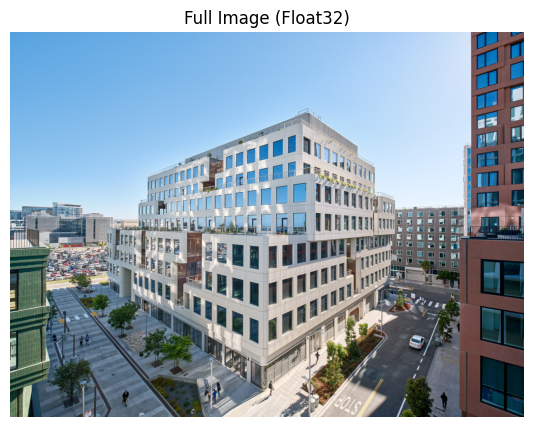

Min value: 0.0
Max value: 1.0
Data type: float32


In [14]:
# 1. Read the image (Defaults to BGR, uint8)
img_bgr = cv2.imread(IMG_PATH)

# 2. Convert BGR to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Convert to float32 and normalize to [0, 1]
# We use .astype(np.float32) and divide by 255.0
IMG = img_rgb.astype("float32") / 255.0

# Visualization
plt.figure(figsize=(10, 5))
# Matplotlib handles float32 [0, 1] images automatically
plt.imshow(IMG)
plt.title(f"Full Image (Float32)")
plt.axis('off')
plt.show()

# Verify the range
print(f"Min value: {IMG.min()}")
print(f"Max value: {IMG.max()}")
print(f"Data type: {IMG.dtype}")

(0.5657239936975769, 0.6322059152070545, 0.6832540118963824)


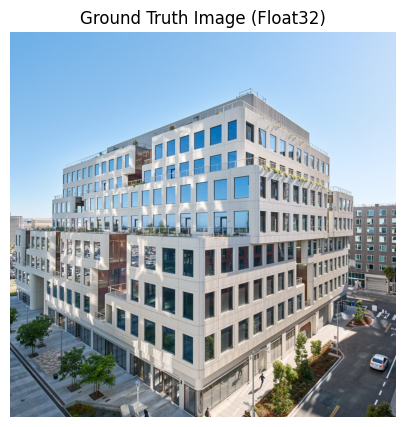

In [15]:
GT_IMG = crop_center(IMG, cropx=LENGTH, cropy=LENGTH)
BG_COLOR = cv2.mean(GT_IMG)[:3]
print(BG_COLOR)
# Visualization
plt.figure(figsize=(10, 5))
# Matplotlib handles float32 [0, 1] images automatically
plt.imshow(GT_IMG)
plt.title(f"Ground Truth Image (Float32)")
plt.axis('off')
plt.show()

In [16]:
IMG_CROP = []
for phi in ANGLES:
    IMG_CROP.append(crop_and_stitch_const_bg(IMG, phi, bg_color=BG_COLOR, L=LENGTH, W=WIDTH, canvas_size=C_SIZE))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

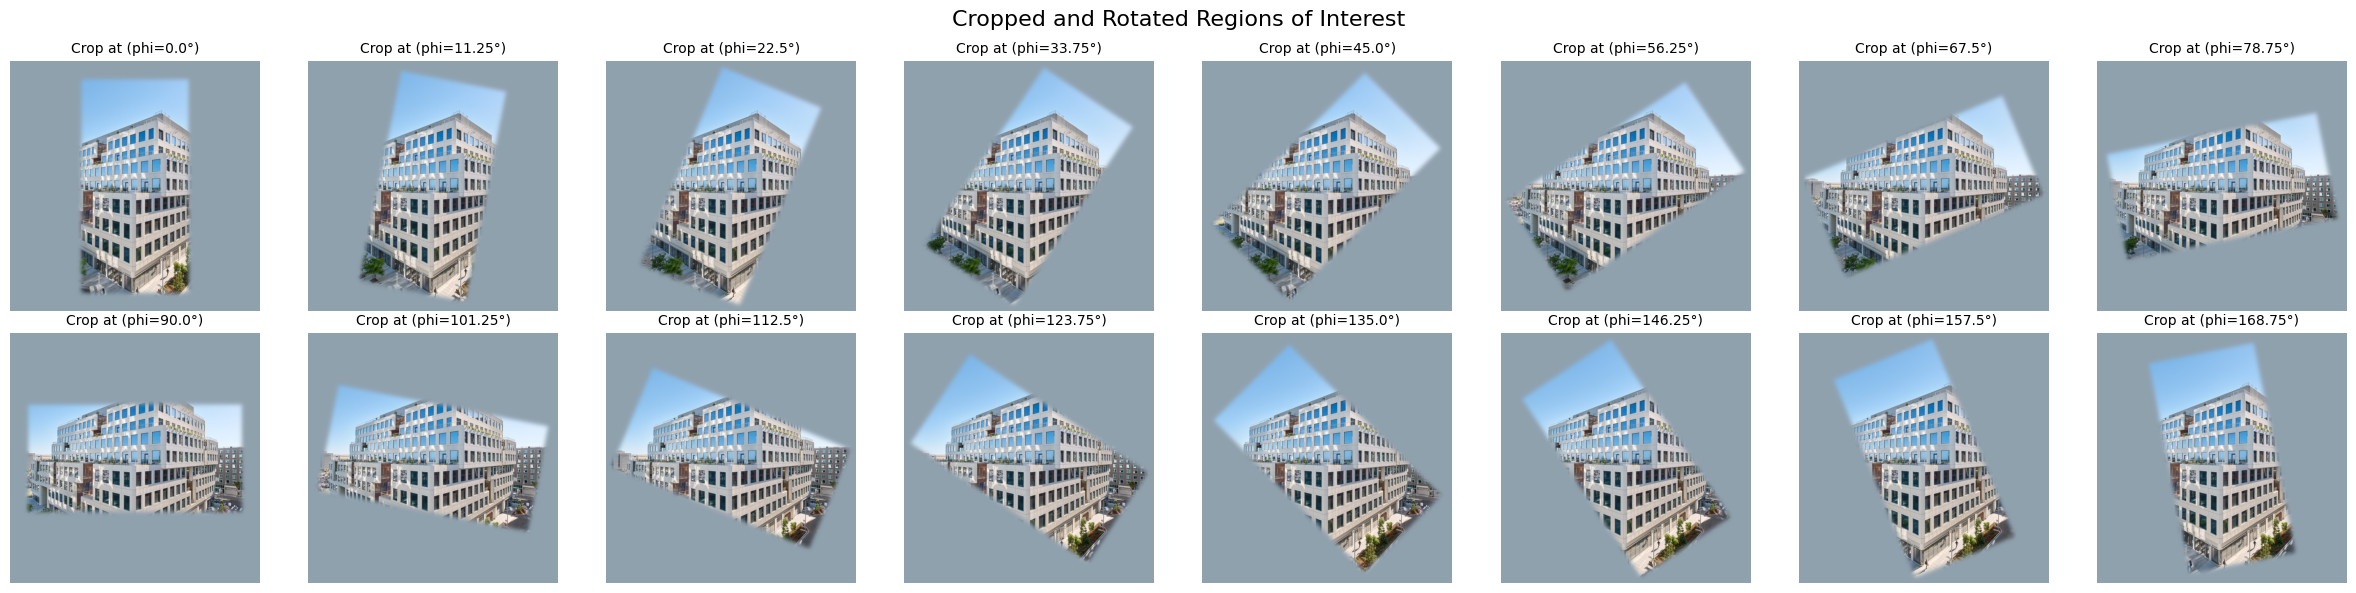

In [17]:
plot_series_angles(IMG_CROP, "Cropped and Rotated Regions of Interest", "Crop at", ANGLES, H_num=H_NUM, W_num=W_NUM)

In [18]:
# 4. Simulate Image Acquisition (Modified for RGB)
APERTURES = []
# img_fft = fftshift(fft2(img, axes=(0, 1), norm="forward"), axes=(0, 1))
IMG_FFTS = [] # Store the FFTs of the cropped images for later use in plotting
G_IMG_FFTS = [] # Store the FFTs of the simulated acquired images (after applying MTF) for later use in plotting
PSFS = []
MTFS = []
SINGLE_AP_IMG = []

for i,phi in enumerate(ANGLES):
    _img_tmp = IMG_CROP[i]
    _img_fft = fftshift(fft2(_img_tmp, axes=(0, 1)), axes=(0, 1))
    _aperture = get_physical_aperture(phi_ap_deg=phi, canvas_H=C_SIZE, canvas_W=C_SIZE, L=AP_L, W=AP_W)
    _psf = get_psf(_aperture)
    _mtf = get_mtf(_psf)
    
    # For RGB images, we need to apply the MTF to each color channel. The MTF is 2D, so we need to expand its dimensions to match the 3D shape of img_fft.
    # _mtf_3d = _mtf[:, :, np.newaxis] 
    # _g_fft = _img_fft * _mtf_3d 
    
    # signal_fr = rfftn(_img_tmp, dim=[-2, -1])
    # kernel_fr = rfftn(_psf, dim=[-2, -1])

    # _g_fft = signal_fr * kernel_fr
    # #output_fr = complex_matmul(signal_fr, kernel_fr)
    # single_ap_img = irfftn(_g_fft, dim=[-2, -1], s=[-1, -1])
    # single_ap_img = ifftshift(single_ap_img, dim=[-2, -1])
    
    # signal_fr = np.fft.fft2(_img_tmp, axes=(0, 1))
    # kernel_fr = np.fft.fft2(np.fft.ifftshift(_psf))  # _psf 是 2D，直接 fft2

    # _g_fft = signal_fr * kernel_fr[:, :, np.newaxis]  # 广播到 RGB 通道

    # single_ap_img = np.fft.ifft2(_g_fft, axes=(0, 1)).real  # 取实部
    # 如果 PSF 没做 fftshift 对中，才需要 ifftshift；一般卷积不需要这步
    # single_ap_img = np.fft.ifftshift(single_ap_img, axes=(0, 1))
    
    single_ap_img = fftconvolve(_img_tmp, _psf[:, :, np.newaxis], mode='same')
    _g_fft = fftshift(fft2(single_ap_img, axes=(0, 1)), axes=(0, 1))
    
    PSFS.append(_psf)
    G_IMG_FFTS.append(_g_fft)
    MTFS.append(_mtf)
    APERTURES.append(_aperture)
    IMG_FFTS.append(_img_fft)
    SINGLE_AP_IMG.append(single_ap_img)
    
    
# def fft_noPad_Conv2D(signal, kernel):
#     signal_fr = rfftn(signal, dim=[-2, -1])
#     kernel_fr = rfftn(kernel, dim=[-2, -1])

#     output_fr = signal_fr * kernel_fr
#     #output_fr = complex_matmul(signal_fr, kernel_fr)
#     output = irfftn(output_fr, dim=[-2, -1], s=[-1, -1])
#     output = ifftshift(output, dim=[-2, -1])

#     return output

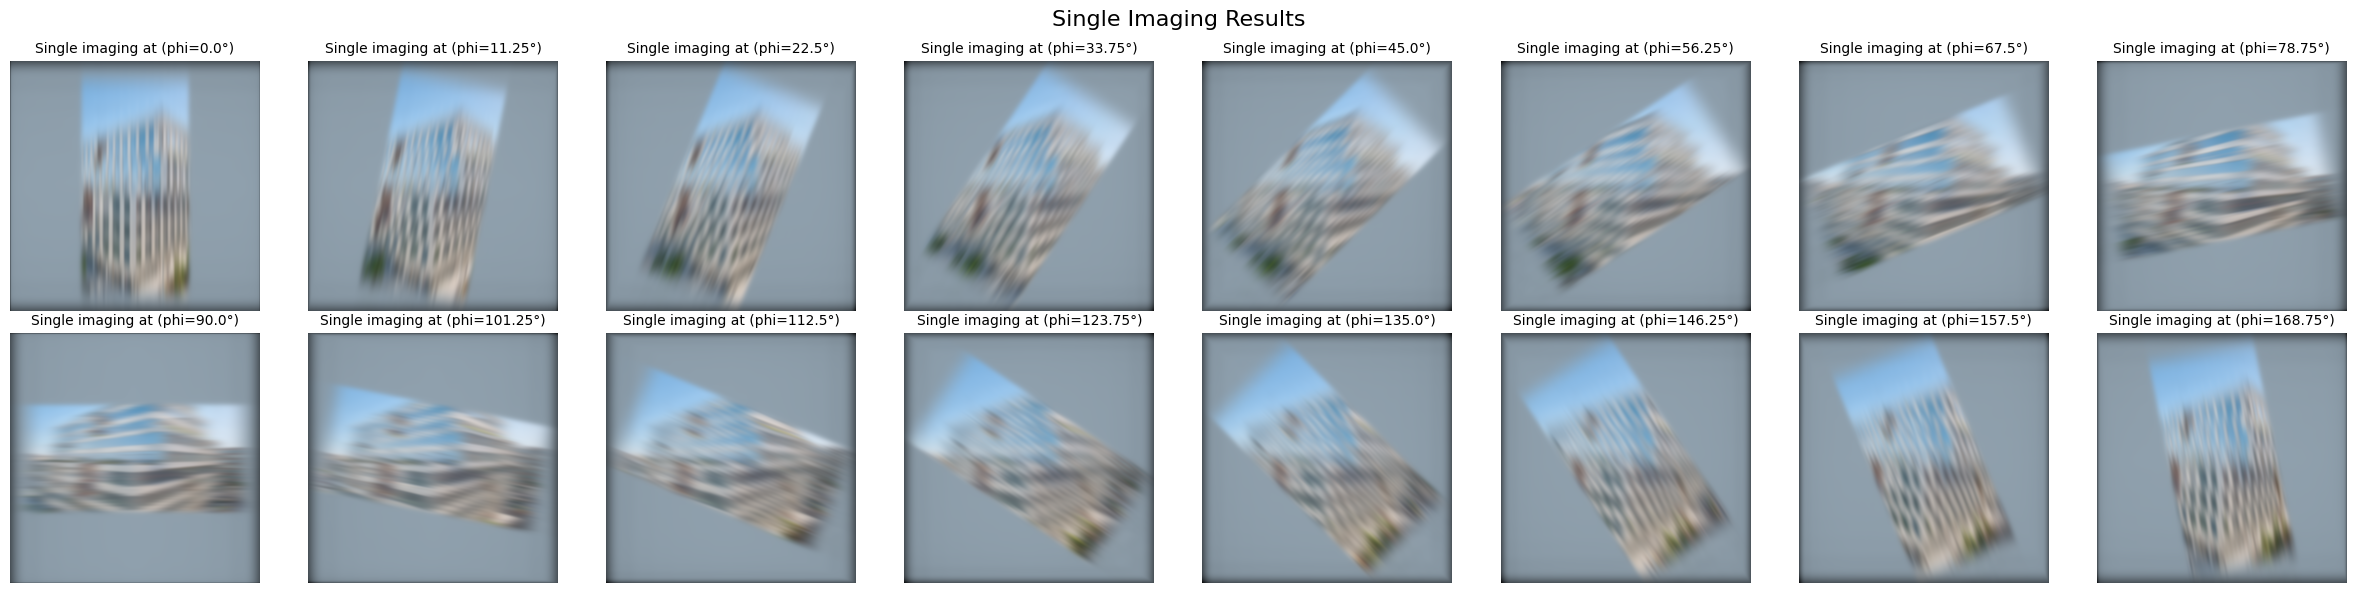

Min value: 0.12601512670516968
Max value: 0.9309790730476379
Data type: float32


In [19]:
# SINGLE_AP_IMG = [] # Store the single-aperture reconstructed images (spatial)

# for i, phi in enumerate(ANGLES):
#     # 1. Inverse FFT to get the spatial domain image for this angle
#     _single_spatial = np.abs(ifft2(ifftshift(G_IMG_FFTS[i], axes=(0, 1)), axes=(0, 1)))
#     _single_spatial = _single_spatial / np.max(_single_spatial)
#     _single_spatial = np.clip(_single_spatial, 0, 1)
    
#     SINGLE_AP_IMG.append(_single_spatial)
    
plot_series_angles(SINGLE_AP_IMG, "Single Imaging Results", "Single imaging at", ANGLES, H_num=H_NUM, W_num=W_NUM)

# Verify the range
print(f"Min value: {SINGLE_AP_IMG[0].min()}")
print(f"Max value: {SINGLE_AP_IMG[0].max()}")
print(f"Data type: {SINGLE_AP_IMG[0].dtype}")

In [20]:
# plot_series_angles(APERTURES, "Apertures", "Aperture at", ANGLES, mode='gray', H_num=H_NUM, W_num=W_NUM)

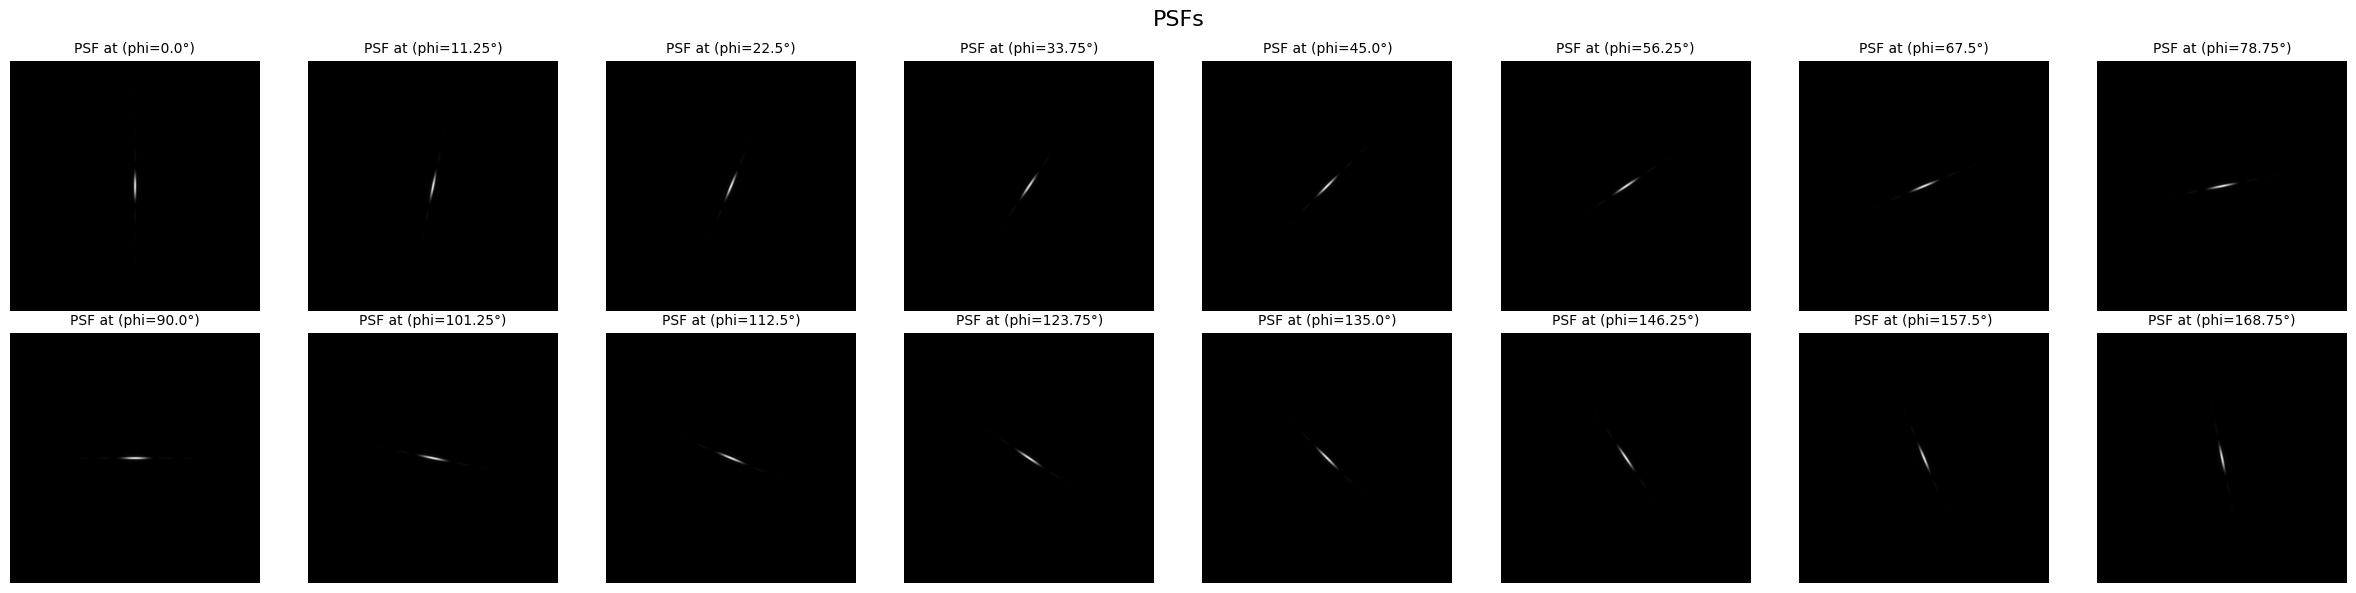

In [21]:
plot_series_angles(PSFS, "PSFs", "PSF at", ANGLES, mode='gray', H_num=H_NUM, W_num=W_NUM)

In [22]:
# plot_series_angles(MTFS, "MTFs", "MTF at", ANGLES, mode='gray', H_num=H_NUM, W_num=W_NUM)

In [23]:
# 5. Reconstruction Algorithm Implementation (Modified for RGB)

# A. Define Combination Masks M_i (Remains 2D as it's a geometric property)
y, x = np.meshgrid(np.linspace(-C_SIZE//2, C_SIZE//2, C_SIZE), 
                   np.linspace(-C_SIZE//2, C_SIZE//2, C_SIZE))
# theta = np.arctan2(y, x)
theta = np.arctan2(-x, y)
MASKS = []
for phi in ANGLES:
    _m_i = get_combination_mask(phi_ap_deg=phi, canvas_H=C_SIZE, canvas_W=C_SIZE, N_apertures=N_APERTURES)
    MASKS.append(_m_i)


# plot_series_angles(MASKS, "Combination Masks", "Mask at", ANGLES, mode='gray', H_num=H_NUM, W_num=W_NUM)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

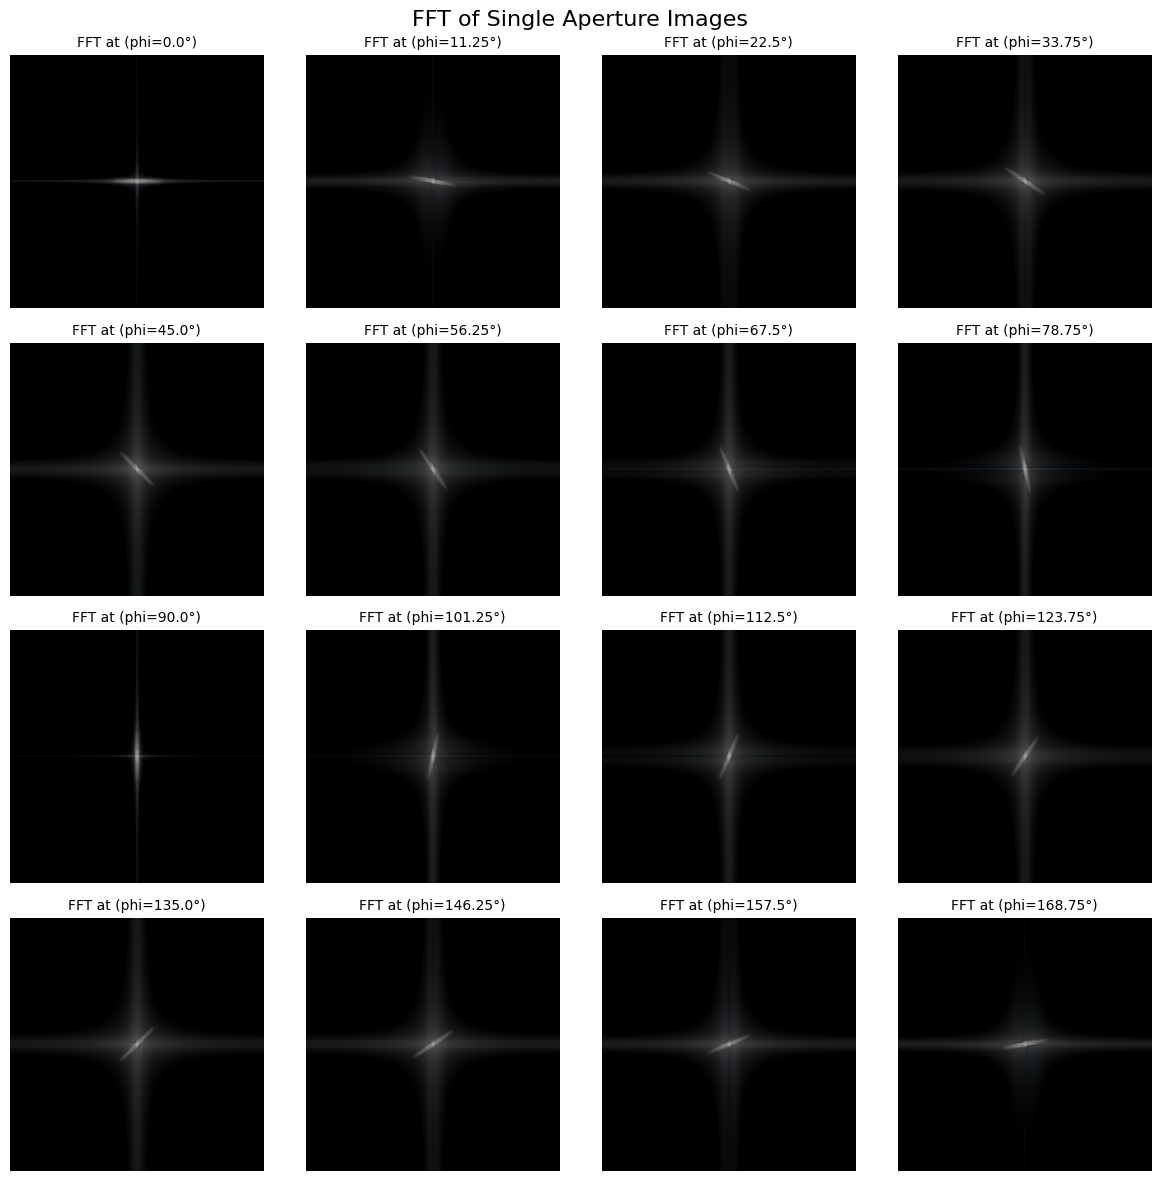

In [24]:
G_IMG_FFT_PLOT = [] # Process convolved FFTs for plotting
for _fft in G_IMG_FFTS:
    G_IMG_FFT_PLOT.append(fft_for_plot(_fft))

plot_series_angles(G_IMG_FFT_PLOT, "FFT of Single Aperture Images", "FFT at", ANGLES, mode='gray', H_num=4, W_num=4)

### Weight map and dictionary

In [31]:
# Calculate the weight stack and contributing indices for each pixel
'''
weight_stack: A 3D boolean array of shape (N, H, W) where N is the number of angles. Each slice weight_stack[i] is a 2D boolean mask indicating which pixels are covered by the
total_weight_map: A 2D array of shape (H, W) where each pixel's value indicates how many masks (angles) cover that pixel. This is essentially the sum of the boolean masks across the first dimension.
contributing_indices: A 2D object array of shape (H, W) where each entry is a tuple containing the indices of the angles that contribute to that pixel. For example, contributing
_indices[r, c] might be (0, 2, 5) indicating that the masks from angles 0, 2, and 5 cover the pixel at row r and column c.
'''
# --- Build the stacked mask array ---

# Stack all masks into a single (N, H, W) boolean array
weight_stack = np.zeros((N_APERTURES, C_SIZE, C_SIZE), dtype=bool)

for i, phi in enumerate(ANGLES):
    _single_map = get_single_weight_map(phi, L=LENGTH-50, W=WIDTH-50, canvas_size=C_SIZE)
    weight_stack[i] = _single_map > 0

# Total weight map: how many masks cover each pixel
TOTAL_WEIGHT_MAP = weight_stack.sum(axis=0).astype(np.float32)  # shape (H, W)

# For ALL pixels, build a (H, W) object array where each entry
# is a tuple of contributing angle indices
contributing_indices = np.empty((C_SIZE, C_SIZE), dtype=object)

# Vectorized approach: transpose to (H, W, N) and use argwhere-style logic
weight_HWN = weight_stack.transpose(1, 2, 0)  # (H, W, N)

# Find all pixels that have at least one mask (skip pure-black borders)
active_pixels = TOTAL_WEIGHT_MAP > 0
rows, cols = np.where(active_pixels)

for r, c in zip(rows, cols):
    contributing_indices[r, c] = tuple(np.where(weight_HWN[r, c])[0])

In [32]:
# Encode each pixel's combination as a hashable tuple, then map to group IDs
group_map_ori = {}
GROUP_ID_ARR = np.zeros((C_SIZE, C_SIZE), dtype=np.int32)
counter = 1

for r, c in zip(rows, cols):
    key = tuple(int(i) for i in np.where(weight_HWN[r, c])[0])
    if key not in group_map_ori:
        group_map_ori[key] = counter
        counter += 1
    GROUP_ID_ARR[r, c] = group_map_ori[key]

# group_map_ori: {(0,): 0, (0, 1): 1, (0, 1, 2): 2, ...}
# GROUP_ID_ARR: (1200, 1200) int array, each pixel labeled by its group
# GROUP_MAP: {0: (0,), 1: (0, 1), 2: (0, 1, 2), ...}
# Build reverse mapping: from group_id to angle indices
GROUP_MAP = {v: k for k, v in group_map_ori.items()}
GROUP_MAP[0] = None  # Group 0 corresponds to pixels with no coverage (black borders)

In [33]:
def query_pixel(r, c, id_array=GROUP_ID_ARR, group_mapping=GROUP_MAP):
    pixel_group = id_array[r, c]
    if pixel_group == 0:
        print("This pixel is not covered by any mask")
    else:
        print(f"Group ID: {pixel_group}, Contributing angle indices: {group_mapping[pixel_group]}")
    return pixel_group, group_mapping[int(pixel_group)]

def px_in_group(target_group, id_array=GROUP_ID_ARR, map=GROUP_MAP):
    ys, xs = np.where(id_array == target_group)
    return list(zip(ys.tolist(), xs.tolist())), map[target_group]

def get_actual_angle(angle_indices, angle_list=ANGLES):
    return [float(angle_list[i]) for i in angle_indices]

def tup_2_list(angle_indices_tuple):
    return list(angle_indices_tuple)


In [34]:
print(GROUP_ID_ARR[600, 600])

141


In [35]:
print(GROUP_MAP[141])

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)


In [28]:
# plt.figure(figsize=(10,5))

# plt.imshow(GROUP_ID_ARR, cmap='viridis')
# plt.title("Group ID Map of Pixel Combinations")
# plt.colorbar(label='Group ID')
# plt.axis('off')

### Unequal mask and reconstruction

In [29]:
def combine_unequal_images(
    ang_id, k=0.01, canvas_size=C_SIZE, ap_length=AP_L, all_angles=ANGLES, 
    g_ffts=G_IMG_FFTS, mtfs=MTFS
    ):
    '''
    Input: ang_id: the index of the angles (e.g., [0,1] for angles[0] and angles[1], which are 0 and 15 degrees in our case)
    '''
    ang_list = []
    g_fft_list = []
    mtf_list = []
    reconstructed_fft = np.zeros((canvas_size, canvas_size, 3), dtype=complex)
    
    for id in ang_id:
        ang_list.append(all_angles[id])
        g_fft_list.append(g_ffts[id])
        mtf_list.append(mtfs[id])
    
    masks = get_combination_masks_not_equal(angle_list_deg=ang_list, canvas_H=canvas_size, canvas_W=canvas_size)
    
    for i in range(len(ang_list)):
        # Expand 2D mask to 3D using np.newaxis to broadcast across R, G, and B
        reconstructed_fft += masks[i][:, :, np.newaxis] * g_fft_list[i]
        
    sum_m_mtf = np.zeros((canvas_size, canvas_size))
    for i in range(len(ang_list)):
        sum_m_mtf += masks[i] * mtf_list[i]
        
    # Ideal target MTF remains 2D
    mtf_ideal = get_circular_mtf(size=canvas_size, L=ap_length) 

    # Calculate H filter (2D)
    h_filter = mtf_ideal / (sum_m_mtf + k)

    # Expand H filter to 3D to apply it to the multi-channel fused spectrum
    rec_img_ori = np.abs(ifft2(ifftshift(reconstructed_fft, axes=(0, 1)), axes=(0, 1)))
    
    # if np.max(rec_img_ori) > 1.2: # Avoid extreme outliers dominating the visualization
    #     rec_img_ori /= np.max(rec_img_ori)  # Normalize for visualization
    #     final_fft = reconstructed_fft * h_filter[:, :, np.newaxis]
    #     reconstructed_img = np.abs(ifft2(ifftshift(final_fft, axes=(0, 1)), axes=(0, 1)))
    # else:
    final_fft = reconstructed_fft * h_filter[:, :, np.newaxis]
    reconstructed_img = np.abs(ifft2(ifftshift(final_fft, axes=(0, 1)), axes=(0, 1)))
    return rec_img_ori, reconstructed_img, final_fft, masks, h_filter

### Combine the weight map and unequal masks

In [30]:
px_group, ang_idxs_tup = query_pixel(500,500)
print(ang_idxs_tup)
if ang_idxs_tup is not None:
    ang_idxs = tup_2_list(ang_idxs_tup)
    print(ang_idxs)

This pixel is not covered by any mask
None


### Stitch the results of all the angle combinations

In [31]:
def fill_corr_px(group_id, ori_img, ori_img_no_h, k=0.05, 
                 id_array=GROUP_ID_ARR, map=GROUP_MAP,
                 c_size=C_SIZE, aperture_length=AP_L, angle_series=ANGLES, g_img_ffts=G_IMG_FFTS, img_mtfs=MTFS
                 ):
    _mask = id_array == group_id
    ang_idxs_tup = map[group_id]
    
    if ang_idxs_tup is None:
        print(f"Error occurred while processing group {group_id}: No contributing angles found.")
        return ori_img
    
    ang_ids = tup_2_list(ang_idxs_tup)
        
    rec_img_no_h, reconstructed_img, _, _, _ = combine_unequal_images(
        ang_id=ang_ids, k=k,
        canvas_size=c_size, ap_length=aperture_length, all_angles=angle_series, g_ffts=g_img_ffts, mtfs=img_mtfs
    )
    
    new_img = ori_img.copy()
    new_img[_mask] = reconstructed_img[_mask]
    
    new_img_no_h = ori_img_no_h.copy()
    new_img_no_h[_mask] = rec_img_no_h[_mask]
    
    return new_img, new_img_no_h, rec_img_no_h, reconstructed_img



In [32]:
combined_img_no_h = np.zeros((C_SIZE, C_SIZE, 3), dtype=np.float64)
combined_img = np.zeros((C_SIZE, C_SIZE, 3), dtype=np.float64)
images_no_h = []
images_final = []

for i in range(1, len(GROUP_MAP)):  # Start from 1 to skip the black border group
    _k = 0.01  # Default k value
    ang_tup = GROUP_MAP[i]
    ang_list = tup_2_list(ang_tup)
    len_temp = len(ang_list)
    if len_temp == 0:
        print(f"Skipping group {i} as it has no contributing angles.")
        continue
    elif 1<= len_temp <= 4:
        _k = 0.1
    elif 5 <= len_temp <= 9:
        _k = 0.05
    elif len_temp >= 10:
        _k = 0.01
    else:
        print(f"Unexpected number of angles ({len_temp}) for group {i}. Using default k={_k}.")
    
    comb_img_cp = combined_img.copy()    
    comb_img_no_h_cp = combined_img_no_h.copy()
    combined_img, combined_img_no_h, single_img_no_h, single_img = fill_corr_px(
        group_id=i, ori_img=comb_img_cp, ori_img_no_h=comb_img_no_h_cp, 
        k=_k
        )
    images_no_h.append(single_img_no_h)
    images_final.append(single_img)


In [33]:
print(GROUP_MAP[1])

(2,)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 599.5, 599.5, -0.5)

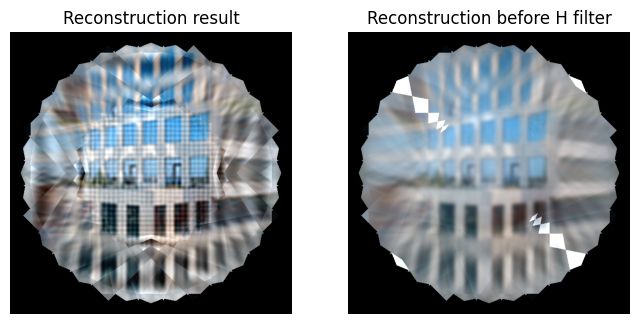

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(combined_img)
axes[0].set_title("Reconstruction result")
axes[0].axis('off')

axes[1].imshow(combined_img_no_h)
axes[1].set_title(f"Reconstruction before H filter")
axes[1].axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 255.5, 255.5, -0.5)

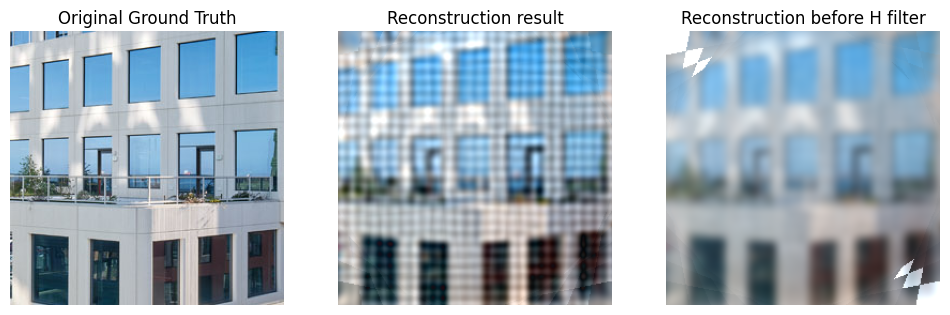

In [35]:
cropped_img = crop_center(IMG, cropx=WIDTH, cropy=WIDTH)
rec_cropped = crop_center(combined_img, cropx=WIDTH, cropy=WIDTH)
ori_rec_cropped = crop_center(combined_img_no_h, cropx=WIDTH, cropy=WIDTH)

fig, axes = plt.subplots(1,3, figsize=(12, 8))
axes[0].imshow(cropped_img)
axes[0].set_title("Original Ground Truth")
axes[0].axis('off')

axes[1].imshow(rec_cropped)
axes[1].set_title(f"Reconstruction result")
axes[1].axis('off')

axes[2].imshow(ori_rec_cropped)
axes[2].set_title(f"Reconstruction before H filter")
axes[2].axis('off')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


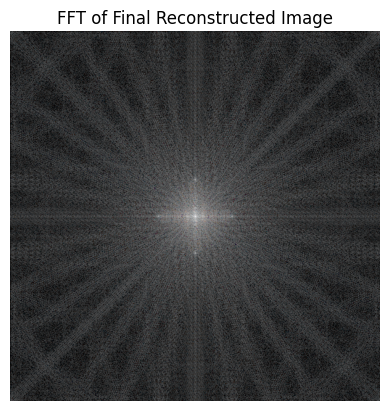

In [36]:
combined_fr = fftshift(fft2(combined_img, axes=(0, 1)), axes=(0, 1))
plt.imshow(fft_for_plot(combined_fr), cmap='gray')
plt.title("FFT of Final Reconstructed Image")
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


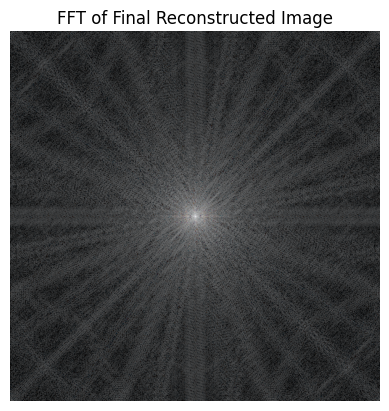

In [37]:
combined_fr = fftshift(fft2(combined_img_no_h, axes=(0, 1)), axes=(0, 1))
plt.imshow(fft_for_plot(combined_fr), cmap='gray')
plt.title("FFT of Final Reconstructed Image")
plt.axis('off')
plt.show()

### Some code for debug/verification

In [38]:
# result_ids = [k for k, v in GROUP_MAP.items() if v is not None and len(v) == 9]

# print(result_ids)

In [39]:
# i = 126
# rec_img_ori_test, reconstructed_img_test, final_fft_test, masks_test, h_filter_test = combine_unequal_images(
#     ang_id=tup_2_list(GROUP_MAP[i]), k=0.01
#     )
# angle_list = get_actual_angle(GROUP_MAP[i])
# print(f"Group ID {i} corresponds to angles: {angle_list}")


# fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(9, 9))

# axes_flat = axes.flatten()

# for j in range(len(masks_test)): 
#     axes_flat[j].imshow(masks_test[j], cmap='gray') 
#     axes_flat[j].set_title(f"Mask for angle {angle_list[j]:.1f}°")
#     axes_flat[j].axis('off')

# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(4,4))
# plt.imshow(reconstructed_img_test)
# plt.title(f"Reconstructed Image for Group ID {i}")
# plt.axis('off')
# plt.show()

In [40]:
# print(f"GT image range: min={GT_IMG.min()}, max={GT_IMG.max()}, total sum: {GT_IMG.sum()}")
# print(f"Reconstructed image range (final): min={rec_img_ori_test.min()}, max={rec_img_ori_test.max()}, total sum: {rec_img_ori_test.sum()}")
# print(f"Reconstructed image range (before averaging): min={reconstructed_img_test.min()}, max={reconstructed_img_test.max()}, total sum: {reconstructed_img_test.sum()}")

# fft_plot = fft_for_plot(final_fft_test)


# fig, axes = plt.subplots(1,4, figsize=(12, 7))

# axes[0].imshow(h_filter_test, cmap='gray')
# axes[0].set_title("Original Ground Truth")
# axes[0].axis('off')

# axes[1].imshow(reconstructed_img_test)
# axes[1].set_title(f"Reconstructed image")
# axes[1].axis('off')

# axes[2].imshow(rec_img_ori_test)
# axes[2].set_title(f"Reconstructed image (before h filter)")
# axes[2].axis('off')

# axes[3].imshow(fft_plot)
# axes[3].set_title(f"FFT of Reconstructed image")
# axes[3].axis('off')

# plt.tight_layout()
# plt.show()

In [41]:
# # Check the DC component (0 frequency) of the fused spectrum for this group
# center = C_SIZE // 2
# for idx in range(len(ANGLES)):
#     dc = G_IMG_FFTS[idx][center, center, :]
#     print(f"Angle {ANGLES[idx]:.0f}°: DC = {np.abs(dc)}")